In [1]:
!pip install -q kaggle

In [1]:
import os
from google.colab import userdata

os.environ["KAGGLE_USERNAME"] = userdata.get ("KAGGLE_USERNAME")
os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_KEY")

print ("Kaggle key generated successfully")

Kaggle key generated successfully


In [3]:
#!kaggle datasets download -d shaunthesheep/microsoft-catsvsdogs-dataset -p /content/data

!kaggle datasets download -d shaunthesheep/microsoft-catsvsdogs-dataset -p /content/data



Dataset URL: https://www.kaggle.com/datasets/shaunthesheep/microsoft-catsvsdogs-dataset
License(s): other
microsoft-catsvsdogs-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [4]:
!kaggle datasets list -s "cats vs dogs"

ref                                                    title                                                size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------  ---------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
shaunthesheep/microsoft-catsvsdogs-dataset             Cats-vs-Dogs                                    825979578  2020-03-12 05:34:30.730000         106360        961  0.875            
biaiscience/dogs-vs-cats                               Dogs vs Cats                                    856265363  2017-12-05 14:03:33.210000          31303        364  0.4375           
pybear/cats-vs-dogs                                    Cats -- VS -- Dogs                              825979578  2020-10-18 13:55:30.950000           3274        105  0.625            
sujaykapadnis/cats-vs-dogs                             Cats Vs Dogs   

In [5]:
import zipfile
import os

zip_path = '/content/data/microsoft-catsvsdogs-dataset.zip'

extract_path = '/content/data'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
  zip_ref.extractall (extract_path)

  print ("Dataset extracted successfully.")

Dataset extracted successfully.


In [6]:
import os
from PIL import Image

base_dir = '/content/data/PetImages'

print (os.listdir(base_dir))
print ("Cat images:", len(os.listdir (os.path.join(base_dir, 'Cat'))))
print ("Dog images:", len(os.listdir (os.path.join(base_dir, 'Dog'))))

['Dog', 'Cat']
Cat images: 12501
Dog images: 12501


In [7]:
import os

# change to your dataset path

classes = os.listdir(base_dir)

remove = 0

for class_name in classes:
    folder_path = os.path.join(base_dir, class_name)

    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_name)
        try:
            with Image.open(img_path) as img:
                img.verify()
        except Exception:
            os.remove(img_path)
            remove += 1

print("Corrupted images removed:", remove)

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Corrupted images removed: 4


In [8]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 150
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    base_dir,
    target_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

val_data = datagen.flow_from_directory(
    base_dir,
    target_size=(IMG_SIZE,IMG_SIZE),
    batch_size = BATCH_SIZE,
    class_mode='binary',
    subset='validation'

)

Found 20000 images belonging to 2 classes.
Found 4998 images belonging to 2 classes.


In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape = (IMG_SIZE, IMG_SIZE,3)), MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'), MaxPooling2D (2,2),
    Conv2D(128,(3,3), activation='relu'), MaxPooling2D (2,2),

    Flatten(),

    Dense (128,activation='relu'),
    Dropout (0.5),


    Dense(1,activation='sigmoid')
    ])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.compile (
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=["accuracy"]
)

In [11]:
history = model.fit (
    train_data,
    validation_data=val_data,
    epochs=10
    )

Epoch 1/10
432/625 ━━━━━━━━━━━━━━━━━━━━ 12s 63ms/step - accuracy: 0.5703 - loss: 0.6822

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


625/625 ━━━━━━━━━━━━━━━━━━━━ 55s 79ms/step - accuracy: 0.6478 - loss: 0.6228 - val_accuracy: 0.7325 - val_loss: 0.5282
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 46s 73ms/step - accuracy: 0.7513 - loss: 0.5102 - val_accuracy: 0.7909 - val_loss: 0.4467
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 46s 74ms/step - accuracy: 0.7965 - loss: 0.4432 - val_accuracy: 0.8095 - val_loss: 0.4182
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 47s 75ms/step - accuracy: 0.8393 - loss: 0.3684 - val_accuracy: 0.8331 - val_loss: 0.3781
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 46s 74ms/step - accuracy: 0.8648 - loss: 0.3146 - val_accuracy: 0.8215 - val_loss: 0.4009
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 45s 71ms/step - accuracy: 0.8952 - loss: 0.2538 - val_accuracy: 0.8471 - val_loss: 0.3644
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 46s 74ms/step - accuracy: 0.9189 - loss: 0.1976 - val_accuracy: 0.8481 - val_loss: 0.3864
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 46s 73ms/step - accuracy: 0.9388 - loss: 0.1546 - val_accurac

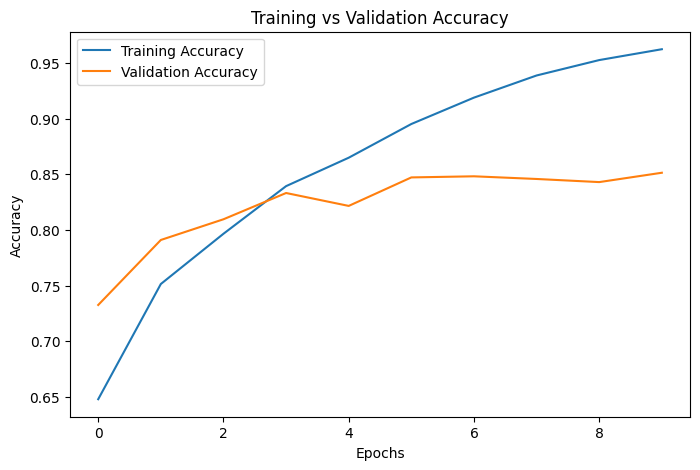

In [12]:
import matplotlib.pyplot as plt

plt.figure (figsize=(8,5))
plt.plot (history.history["accuracy"], label="Training Accuracy")
plt.plot (history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel ("Epochs")
plt.ylabel ("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()


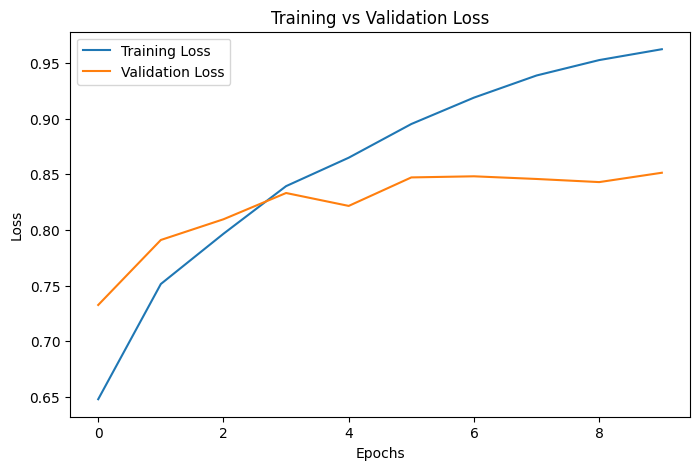

In [13]:
plt.figure (figsize=(8,5))
plt.plot (history.history["accuracy"], label="Training Loss")
plt.plot (history.history["val_accuracy"], label="Validation Loss")
plt.xlabel ("Epochs")
plt.ylabel ("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()


In [14]:
loss, accuracy = model.evaluate (val_data)
print ("Validation Loss:", loss)
print ("Validation Accuracy: ", accuracy)


157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 58ms/step - accuracy: 0.8513 - loss: 0.4671
Validation Loss: 0.4671149253845215
Validation Accuracy:  0.8513405323028564


In [15]:
model.save ("/content/cat_dog_basic_cnn_model.h5")
print ("Model saved successfully.")

Model saved successfully.


Saving cat1.jfif to cat1 (1).jfif
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


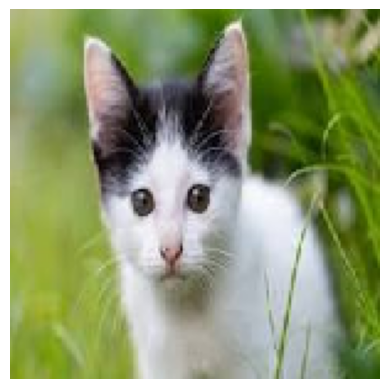

Predicted class: Cat
Confidence: 0.9065062


In [19]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

uploaded = files.upload()

for file_name in uploaded.keys():

    img_path = file_name

    img = image.load_img(
        img_path,
        target_size=(IMG_SIZE, IMG_SIZE)
    )

    img_array = image.img_to_array(img)

    img_array = np.expand_dims(img_array, axis=0)

    # Optional if training images were rescaled by 1./255
    img_array = img_array / 255.0

    prediction = model.predict(img_array)

    plt.imshow(img)
    plt.axis("off")
    plt.show()

    if prediction[0][0] > 0.5:
        print("Predicted class: Dog")
        print("Confidence:", prediction[0][0])
    else:
        print("Predicted class: Cat")
        print("Confidence:", 1 - prediction[0][0])